<a href="https://colab.research.google.com/github/Alex-Actuary/Physics/blob/main/notebooks/All%C3%A9e%20de%20von%20K%C3%A1rm%C3%A1n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Grille 251x101, 24608 inconnues, 10000 pas, solveur = lu
  t =   10.0/200.0  Cd = 0.254  Cl = -0.023  (   16 s)
  t =   20.0/200.0  Cd = 0.274  Cl =  0.057  (   24 s)
  t =   30.0/200.0  Cd = 0.291  Cl = -0.087  (   33 s)
  t =   40.0/200.0  Cd = 0.284  Cl = -0.077  (   43 s)
  t =   50.0/200.0  Cd = 0.298  Cl =  0.107  (   51 s)
  t =   60.0/200.0  Cd = 0.285  Cl =  0.074  (   61 s)
  t =   70.0/200.0  Cd = 0.298  Cl = -0.111  (   70 s)
  t =   80.0/200.0  Cd = 0.285  Cl = -0.070  (   79 s)
  t =   90.0/200.0  Cd = 0.298  Cl =  0.114  (   88 s)
  t =  100.0/200.0  Cd = 0.286  Cl =  0.065  (   97 s)
  t =  110.0/200.0  Cd = 0.297  Cl = -0.117  (  106 s)
  t =  120.0/200.0  Cd = 0.286  Cl = -0.059  (  115 s)
  t =  130.0/200.0  Cd = 0.297  Cl =  0.119  (  125 s)
  t =  140.0/200.0  Cd = 0.286  Cl =  0.054  (  134 s)
  t =  150.0/200.0  Cd = 0.297  Cl = -0.121  (  143 s)
  t =  160.0/200.0  Cd = 0.286  Cl = -0.049  (  152 s)
  t =  170.0/200.0  Cd = 0.297  Cl =  0.123  (  162 s)
  t =  1

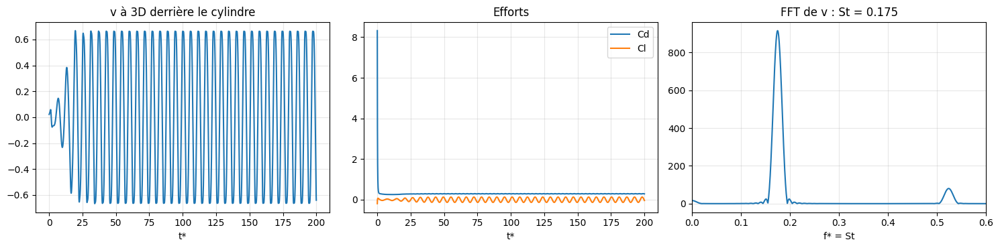

Animation enregistrée : karman.gif


In [12]:
# -*- coding: utf-8 -*-
"""
Allée de von Kármán : écoulement 2D incompressible autour d'un cylindre
Formulation tourbillon-fonction de courant (ω-ψ), Re = 100, variables adimensionnelles.

  u = dψ/dy , v = -dψ/dx , ω = dv/dx - du/dy = -∇²ψ
  dω/dt + u dω/dx + v dω/dy = (1/Re) ∇²ω

Schéma :
  - maillage cartésien uniforme, cylindre en "escalier" (rayon de masque R + h/2)
  - convection : upwind d'ordre 3 ; diffusion : différences centrées d'ordre 2
  - temps : Heun (RK2) explicite, avec re-résolution de Poisson à chaque étage
  - Poisson : LU creuse (par défaut, très rapide) ou SOR rouge-noir (SOLVER = "sor")
  - ω pariétal : formule de Thom, ω_p = -2 (ψ_voisin - ψ_p) / h²
  - efforts : pression par dp/ds = -ν dω/dn le long de la paroi, cisaillement ν ω_p
"""

# ======================= PARAMÈTRES À MODIFIER =======================
N_FRAMES      = 120     # nombre d'images de l'animation
FPS           = 20       # images par seconde de l'animation
T_END         = 200.0    # temps final adimensionnel (t* = t U/D)
T_ANIM_START  = 140.0    # début de la fenêtre filmée (après le régime transitoire)
RE            = 100.0
H             = 0.08     # pas d'espace (D = 1 -> 12,5 mailles par diamètre)
DT            = 0.02     # pas de temps (CFL ~ 0,4 ; diffusion OK)
SOLVER        = "lu"     # "lu" (rapide) ou "sor" (plus lent)
SOR_OMEGA, SOR_TOL, SOR_MAXIT = 1.9, 1e-6, 400
SAVE_GIF      = True
# =====================================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.patches import Circle
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import splu

# ---------------- Géométrie et grille ----------------
LX, LY = 20.0, 8.0
XC, YC, R = 5.0, 4.0, 0.5
NU = 1.0 / RE
h, h2 = H, H * H
Nx, Ny = int(round(LX / h)) + 1, int(round(LY / h)) + 1
x, y = np.arange(Nx) * h, np.arange(Ny) * h
X, Y = np.meshgrid(x, y)                      # tableaux (Ny, Nx) : [j, i]
J, I = np.meshgrid(np.arange(Ny), np.arange(Nx), indexing="ij")

solid = (X - XC) ** 2 + (Y - YC) ** 2 <= (R + 0.5 * h) ** 2
fluid = ~solid
nbf = np.zeros_like(solid)
nbf[1:-1, 1:-1] = (fluid[:-2, 1:-1] | fluid[2:, 1:-1] |
                   fluid[1:-1, :-2] | fluid[1:-1, 2:])
wall = solid & nbf                            # nœuds solides au contact du fluide

fint = fluid.copy()                           # nœuds fluides où l'on avance ω
fint[0, :] = fint[-1, :] = False
fint[:, 0] = fint[:, -1] = False

# ψ imposé : entrée ψ=y, bas ψ=0, haut ψ=LY, cylindre ψ=YC
psi_fix = Y.copy()
psi_fix[solid] = YC

# ---------------- Poisson : inconnues et matrice ----------------
unk = fluid.copy()
unk[0, :] = unk[-1, :] = False
unk[:, 0] = False                             # la colonne de sortie est inconnue (Neumann)
js, is_ = np.nonzero(unk)
n_unk = len(js)
idx = -np.ones((Ny, Nx), dtype=int)
idx[js, is_] = np.arange(n_unk)

rows, cols, vals = [], [], []
b_fix = np.zeros(n_unk)
coef = np.full(n_unk, h2)
for k in range(n_unk):
    j, i = js[k], is_[k]
    if i == Nx - 1:                           # sortie libre : dψ/dx = 0
        rows += [k, k]; cols += [k, idx[j, i - 1]]; vals += [1.0, -1.0]
        coef[k] = 0.0
    else:
        rows.append(k); cols.append(k); vals.append(4.0)
        for jj, ii in ((j + 1, i), (j - 1, i), (j, i + 1), (j, i - 1)):
            m = idx[jj, ii]
            if m >= 0:
                rows.append(k); cols.append(m); vals.append(-1.0)
            else:
                b_fix[k] += psi_fix[jj, ii]
A = coo_matrix((vals, (rows, cols)), shape=(n_unk, n_unk)).tocsc()
lu = splu(A) if SOLVER == "lu" else None

# masques pour SOR rouge-noir (inconnues hors colonne de sortie)
sor_in = unk.copy(); sor_in[:, -1] = False
sor_masks = [sor_in & (((I + J) % 2) == c) for c in (0, 1)]


def solve_psi(w, psi_old):
    """Résout ∇²ψ = -ω avec les conditions aux limites."""
    if SOLVER == "lu":
        psi = psi_fix.copy()
        psi[js, is_] = lu.solve(coef * w[js, is_] + b_fix)
        return psi
    psi = psi_old.copy()
    for it in range(SOR_MAXIT):
        for m in sor_masks:
            gs = 0.25 * (np.roll(psi, 1, 0) + np.roll(psi, -1, 0) +
                         np.roll(psi, 1, 1) + np.roll(psi, -1, 1) + h2 * w)
            psi[m] += SOR_OMEGA * (gs[m] - psi[m])
            psi[:, -1] = psi[:, -2]
        if it % 10 == 0:
            res = np.abs(0.25 * (psi[2:, 1:-1] + psi[:-2, 1:-1] + psi[1:-1, 2:] +
                                 psi[1:-1, :-2] + h2 * w[1:-1, 1:-1]) -
                         psi[1:-1, 1:-1])[fint[1:-1, 1:-1]].max()
            if res < SOR_TOL:
                break
    return psi


# ---------------- Conditions aux limites sur ω ----------------
wj, wi = np.nonzero(wall)
DIRS = ((1, 0), (-1, 0), (0, 1), (0, -1))     # (dj, di)
w_valid = np.array([fluid[wj + dj, wi + di] for dj, di in DIRS])   # (4, nw)
w_cnt = w_valid.sum(axis=0)


def apply_bc(w, psi):
    s = np.zeros(len(wj))
    for d, (dj, di) in enumerate(DIRS):
        s += w_valid[d] * (psi[wj + dj, wi + di] - YC)
    w[wj, wi] = -2.0 * s / (w_cnt * h2)       # Thom (moyenne sur les voisins fluides)
    w[solid & ~wall] = 0.0
    w[0, :] = 0.0; w[-1, :] = 0.0; w[:, 0] = 0.0   # glissement haut/bas, entrée uniforme
    w[:, -1] = w[:, -2]                       # sortie : dω/dx = 0


# ---------------- Second membre : dω/dt ----------------
def rhs(w, psi):
    u = np.zeros_like(w); v = np.zeros_like(w)
    u[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * h)
    v[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * h)
    uu, vv = u[1:-1, 1:-1], v[1:-1, 1:-1]

    P = np.pad(w, 2, mode="edge")
    rs, cs = slice(3, Ny + 1), slice(3, Nx + 1)
    w0 = P[rs, cs]
    xm2, xm1, xp1, xp2 = P[rs, 1:Nx - 1], P[rs, 2:Nx], P[rs, 4:Nx + 2], P[rs, 5:Nx + 3]
    ym2, ym1, yp1, yp2 = P[1:Ny - 1, cs], P[2:Ny, cs], P[4:Ny + 2, cs], P[5:Ny + 3, cs]

    dwdx = np.where(uu > 0, 2 * xp1 + 3 * w0 - 6 * xm1 + xm2,
                    -xp2 + 6 * xp1 - 3 * w0 - 2 * xm1) / (6 * h)
    dwdy = np.where(vv > 0, 2 * yp1 + 3 * w0 - 6 * ym1 + ym2,
                    -yp2 + 6 * yp1 - 3 * w0 - 2 * ym1) / (6 * h)
    lap = (xp1 + xm1 + yp1 + ym1 - 4 * w0) / h2

    dw = np.zeros_like(w)
    dw[1:-1, 1:-1] = (-(uu * dwdx + vv * dwdy) + NU * lap) * fint[1:-1, 1:-1]
    return dw


# ---------------- Efforts sur le cylindre (Cd, Cl) ----------------
th = np.arctan2(wj * h - YC, wi * h - XC)
order = np.argsort(th)
fj, fi, th = wj[order], wi[order], th[order]
f_valid = w_valid[:, order]
nx_, ny_ = np.cos(th), np.sin(th)
dth = np.roll(th, -1) - th; dth[-1] += 2 * np.pi
wgt = 0.5 * (dth + np.roll(dth, 1))
a = np.array([f_valid[d] * np.maximum(h * (di * nx_ + dj * ny_), 0.0)
              for d, (dj, di) in enumerate(DIRS)])
a_den = np.maximum((a ** 2).sum(axis=0), 1e-12)


def forces(w):
    wp = w[fj, fi]
    g = sum(a[d] * (w[fj + dj, fi + di] - wp) for d, (dj, di) in enumerate(DIRS)) / a_den
    f = R * NU * g                                       # dp/dθ = R ν dω/dn
    seg = 0.5 * (f + np.roll(f, -1)) * dth
    pc = np.concatenate(([0.0], np.cumsum(seg[:-1])))
    pc -= seg.sum() * (th - th[0]) / (2 * np.pi)         # fermeture de la boucle
    Fx = np.sum((-pc * nx_ - NU * wp * ny_) * R * wgt)   # t = (sinθ, -cosθ)
    Fy = np.sum((-pc * ny_ + NU * wp * nx_) * R * wgt)
    return 2.0 * Fx, 2.0 * Fy                            # /(0,5 ρ U² D), D=U=ρ=1


# ---------------- Initialisation (avec perturbation) ----------------
w = np.zeros((Ny, Nx))
w += 1.0 * np.exp(-((X - (XC + 1.5)) ** 2 + (Y - (YC + 0.3)) ** 2) / 0.1) * fint  # perturbation
psi = solve_psi(w, psi_fix.copy()); apply_bc(w, psi)

NT = int(round(T_END / DT))
f_steps = np.unique(np.clip(np.round(np.linspace(T_ANIM_START, T_END, N_FRAMES) / DT)
                            .astype(int), 1, NT))
frames, frame_t = [], []
jp, ip = int(round(YC / h)), int(round((XC + 3.0) / h))   # sonde : 3D derrière le cylindre
t_hist, v_hist, cd_hist, cl_hist = [], [], [], []

print(f"Grille {Nx}x{Ny}, {n_unk} inconnues, {NT} pas, solveur = {SOLVER}")
t0 = time.time()
for n in range(1, NT + 1):
    k1 = rhs(w, psi)
    w1 = w + DT * k1
    psi1 = solve_psi(w1, psi); apply_bc(w1, psi1)
    k2 = rhs(w1, psi1)
    w = w + 0.5 * DT * (k1 + k2)
    psi = solve_psi(w, psi); apply_bc(w, psi)

    cd, cl = forces(w)
    t_hist.append(n * DT); v_hist.append(-(psi[jp, ip + 1] - psi[jp, ip - 1]) / (2 * h))
    cd_hist.append(cd); cl_hist.append(cl)
    if n in f_steps:
        frames.append(w.astype(np.float32).copy()); frame_t.append(n * DT)
    if n % 500 == 0:
        print(f"  t = {n*DT:6.1f}/{T_END}  Cd = {cd:5.3f}  Cl = {cl:6.3f}  "
              f"({time.time()-t0:5.0f} s)")
    if not np.isfinite(w).all():
        raise RuntimeError("Divergence numérique : réduire DT ou H.")

t_hist, v_hist = np.array(t_hist), np.array(v_hist)
cd_hist, cl_hist = np.array(cd_hist), np.array(cl_hist)

# ---------------- Post-traitement : FFT, St, Cd, Cl ----------------
mask = t_hist >= 0.5 * T_END                  # on ignore le transitoire
sig = v_hist[mask] - v_hist[mask].mean()
nfft = 2 ** 16
spec = np.abs(np.fft.rfft(sig * np.hanning(len(sig)), nfft))
freq = np.fft.rfftfreq(nfft, DT)
f_peak = freq[np.argmax(spec[1:]) + 1]
St = f_peak * 1.0 / 1.0                       # D = U = 1
St_ref = 0.2684 - 1.0356 / np.sqrt(RE)        # Williamson (49 < Re < 178)
Cd_mean, Cl_amp = cd_hist[mask].mean(), 0.5 * (cl_hist[mask].max() - cl_hist[mask].min())

print("\n========== RÉSULTATS ==========")
print(f"St   = {St:.4f}   (réf. Williamson ~ {St_ref:.4f}, erreur {100*(St/St_ref-1):+.1f} %)")
print(f"Cd   = {Cd_mean:.3f}  (réf. ~1,33 non confiné ; ~1,4-1,5 avec blocage 12,5 %)")
print(f"Cl'  = {Cl_amp:.3f}  (amplitude, réf. ~0,33)")
print("Blocage D/H = 12,5 % : tend à augmenter St et Cd par rapport au cas non confiné.")

fig2, ax2 = plt.subplots(1, 3, figsize=(15, 3.8))
ax2[0].plot(t_hist, v_hist); ax2[0].set(title="v à 3D derrière le cylindre", xlabel="t*")
ax2[1].plot(t_hist, cd_hist, label="Cd"); ax2[1].plot(t_hist, cl_hist, label="Cl")
ax2[1].set(title="Efforts", xlabel="t*"); ax2[1].legend()
ax2[2].plot(freq, spec); ax2[2].set(xlim=(0, 0.6), title=f"FFT de v : St = {St:.3f}",
                                     xlabel="f* = St")
for ax_ in ax2: ax_.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("karman_diagnostics.png", dpi=120); plt.show()

# ---------------- Animation de la vorticité ----------------
fig, ax = plt.subplots(figsize=(10, 4.2))
im = ax.imshow(frames[0], origin="lower", extent=[-h / 2, LX + h / 2, -h / 2, LY + h / 2],
               cmap="RdBu_r", vmin=-3, vmax=3, interpolation="bilinear", aspect="equal")
ax.add_patch(Circle((XC, YC), R, color="0.3", zorder=3))
fig.colorbar(im, ax=ax, label="ω D/U", fraction=0.025, pad=0.02)
ax.set(xlabel="x/D", ylabel="y/D")
title = ax.set_title(f"Vorticité, Re = {RE:.0f}, t* = {frame_t[0]:.1f}")


def update(k):
    im.set_data(frames[k]); title.set_text(f"Vorticité, Re = {RE:.0f}, t* = {frame_t[k]:.1f}")
    return im, title


plt.rcParams["animation.embed_limit"] = 100
anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / FPS, blit=False)
if SAVE_GIF:
    anim.save("karman.gif", writer=animation.PillowWriter(fps=FPS))
    print("Animation enregistrée : karman.gif")
plt.close(fig)
try:                                          # affichage direct dans Colab / Jupyter
    from IPython.display import HTML, display
    display(HTML(anim.to_jshtml()))
except Exception:
    pass